# **Evaluasi bacaan sensor dengan data polusi udara PM2.5, PM10, dan CO dari data AQI.in**

## **Import Library**

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm

In [2]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\Muhammad Mahdi\PrediksiPolusiUdara\notebooks


## **Load Data**

In [3]:
df_sensor = pd.read_csv(r'..\data\raw\feeds (1).csv')

df_aqi = pd.read_excel(r'C:\Users\Muhammad Mahdi\PrediksiPolusiUdara\data\raw\AQI.in_data_2025-06-21_to_2025-06-30.xlsx')

df_sensor = df_sensor.rename(columns={
    'field1': 'Temperature',
    'field2': 'Humidity',
    'field3': 'PM2.5',
    'field4': 'PM10',
    'field5': 'CO',
    'field6': 'CO2'
})

df_sensor.drop(columns=['entry_id', 'latitude', 'longitude', 'elevation', 'status'], inplace=True)

df_sensor['created_at'] = pd.to_datetime(df_sensor['created_at'])

df_sensor = df_sensor[(df_sensor['created_at'] >= '2025-06-21') & (df_sensor['created_at'] < '2025-07-01')]

df_sensor = df_sensor.set_index('created_at')

print(df_sensor.head())
print(df_sensor.tail())

                           Temperature  Humidity  PM2.5   PM10       CO  \
created_at                                                                
2025-06-21 00:00:05+07:00         25.8      79.9   81.8  102.5  0.66225   
2025-06-21 00:00:55+07:00         25.8      79.8   71.6   90.6  0.64170   
2025-06-21 00:01:44+07:00         25.7      80.0   48.4   63.3  0.67559   
2025-06-21 00:02:34+07:00         25.6      80.4   93.8  118.4  0.64911   
2025-06-21 00:03:23+07:00         25.6      80.6   43.3   58.1  0.63619   

                                 CO2  
created_at                            
2025-06-21 00:00:05+07:00  403.42593  
2025-06-21 00:00:55+07:00  403.48303  
2025-06-21 00:01:44+07:00  403.36960  
2025-06-21 00:02:34+07:00  403.44012  
2025-06-21 00:03:23+07:00  403.36261  
                           Temperature  Humidity  PM2.5  PM10       CO  \
created_at                                                               
2025-06-30 23:56:19+07:00         24.7      82.3   25

In [4]:
df_sensor

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-21 00:00:05+07:00,25.8,79.9,81.8,102.5,0.66225,403.42593
2025-06-21 00:00:55+07:00,25.8,79.8,71.6,90.6,0.64170,403.48303
2025-06-21 00:01:44+07:00,25.7,80.0,48.4,63.3,0.67559,403.36960
2025-06-21 00:02:34+07:00,25.6,80.4,93.8,118.4,0.64911,403.44012
2025-06-21 00:03:23+07:00,25.6,80.6,43.3,58.1,0.63619,403.36261
...,...,...,...,...,...,...
2025-06-30 23:56:19+07:00,24.7,82.3,25.8,44.5,0.56777,403.81860
2025-06-30 23:57:08+07:00,24.8,81.9,25.7,44.3,0.60562,403.81088
2025-06-30 23:57:57+07:00,24.7,81.7,24.4,43.1,0.57621,403.75714


In [5]:
scaler = StandardScaler()
features = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'CO', 'CO2']
X = df_sensor[features]

X_scaled = scaler.fit_transform(X)

In [6]:
import joblib

# Load model
dbscan_model = joblib.load(r"../data/model/fault_detection_dbscan.pkl")

# Sekarang dbscan_model siap digunakan
print(dbscan_model)


DBSCAN(eps=0.4, min_samples=6)


In [7]:
# === Grid search range ===
eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = range(3, 15)

results = []

for eps in tqdm(eps_values):
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Hitung silhouette hanya jika jumlah cluster valid
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1

        # Hitung Coefficient Correlation (CC) hanya jika n_clusters > 0
        cc = (min_samples * eps / (n_clusters * 10)) if n_clusters > 0 else np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': score,
            'cc': cc
        })

# === Simpan sebagai DataFrame ===
results_df = pd.DataFrame(results)

  0%|          | 0/17 [00:00<?, ?it/s]

In [8]:
# Filter: minimal 2 cluster & score valid
valid_results = results_df[(results_df['n_clusters'] >= 2) & (results_df['silhouette_score'] > 0)]

# Urutkan berdasarkan kombinasi terbaik: silhouette tinggi + cc kecil
best = valid_results.sort_values(by=['cc', 'silhouette_score'], ascending=[True, False])
print("Top kombinasi parameter terbaik (berdasarkan jurnal):")
print(best.head(10))

Top kombinasi parameter terbaik (berdasarkan jurnal):
    eps  min_samples  n_clusters  n_noise  silhouette_score        cc
13  0.4            4           6       72          0.020947  0.026667
36  0.6            3           5       16          0.140625  0.036000
25  0.5            4           4       48          0.196814  0.050000
26  0.5            5           4       53          0.193833  0.062500
48  0.7            3           3       12          0.243084  0.070000
37  0.6            4           3       24          0.281878  0.080000
60  0.8            3           3        7          0.245401  0.080000
72  0.9            3           3        6          0.245382  0.090000
27  0.5            6           3       58          0.199190  0.100000
49  0.7            4           2       16          0.309379  0.140000


In [9]:
# Clustering dengan DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)


df_sensor['dbscan_cluster'] = dbscan_labels
df_sensor['dbscan_outlier'] = dbscan_labels == -1

# Cek jika bisa hitung silhouette score
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = None

print("DBSCAN - Jumlah cluster:", n_clusters_dbscan)
print("DBSCAN - Jumlah outlier:", df_sensor['dbscan_outlier'].sum())
print("DBSCAN Silhouette Score:", round(dbscan_silhouette, 3) if dbscan_silhouette else "Tidak dapat dihitung")

DBSCAN - Jumlah cluster: 6
DBSCAN - Jumlah outlier: 72
DBSCAN Silhouette Score: 0.021


In [14]:
# Drop data outlier
df_clean = df_sensor[df_sensor['dbscan_outlier'] == False].copy()

# Drop kolom cluster dan outlier
df_clean = df_clean.drop(columns=['dbscan_cluster', 'dbscan_outlier'])

# Tampilkan data bersih
print(df_clean.head())
print(df_clean.tail())


                           Temperature  Humidity  PM2.5   PM10       CO  \
created_at                                                                
2025-06-21 00:00:05+07:00         25.8      79.9   81.8  102.5  0.66225   
2025-06-21 00:00:55+07:00         25.8      79.8   71.6   90.6  0.64170   
2025-06-21 00:01:44+07:00         25.7      80.0   48.4   63.3  0.67559   
2025-06-21 00:02:34+07:00         25.6      80.4   93.8  118.4  0.64911   
2025-06-21 00:03:23+07:00         25.6      80.6   43.3   58.1  0.63619   

                                 CO2  
created_at                            
2025-06-21 00:00:05+07:00  403.42593  
2025-06-21 00:00:55+07:00  403.48303  
2025-06-21 00:01:44+07:00  403.36960  
2025-06-21 00:02:34+07:00  403.44012  
2025-06-21 00:03:23+07:00  403.36261  
                           Temperature  Humidity  PM2.5  PM10       CO  \
created_at                                                               
2025-06-30 23:56:19+07:00         24.7      82.3   25

In [15]:
df_resampled = df_clean.resample('D').mean().interpolate(method='linear')

In [16]:
df_resampled

,Temperature,Humidity,PM2.5,PM10,CO,CO2
created_at,,,,,,
2025-06-21 00:00:00+07:00,26.535074,81.027122,67.575608,87.831395,0.562067,403.474040
2025-06-22 00:00:00+07:00,26.706698,81.559107,68.404583,90.338073,0.461993,403.466973
2025-06-23 00:00:00+07:00,26.757169,76.469586,50.864367,69.498800,0.431280,403.611610
2025-06-24 00:00:00+07:00,26.508917,79.586116,71.193836,102.761460,0.867570,405.599358
2025-06-25 00:00:00+07:00,26.537367,79.655694,68.553974,100.655575,0.966070,405.878995
2025-06-26 00:00:00+07:00,27.075984,73.755490,39.533001,63.049736,1.043497,406.123383
2025-06-27 00:00:00+07:00,27.238822,72.416166,36.271635,52.481070,1.348488,407.328424
2025-06-28 00:00:00+07:00,25.014329,84.342866,28.614878,40.039573,1.296273,406.624541
2025-06-29 00:00:00+07:00,25.630130,80.085291,30.893238,44.322123,1.044667,405.621375


In [11]:
df_aqi

,Tanggal,AQIin_PM2.5 (µg/m³),AQIin_PM10 (µg/m³),AQIin_CO (ppb)
0,2025-06-21,13,22,237
1,2025-06-22,12,19,387
2,2025-06-23,13,21,264
3,2025-06-24,13,27,193
4,2025-06-25,14,27,166
5,2025-06-26,14,25,149
6,2025-06-27,14,24,159
7,2025-06-28,14,25,210
8,2025-06-29,17,31,172
9,2025-06-30,18,36,187


**Mengubah skala CO ppb menjadi ppm**

In [12]:
df_aqi['AQIin_CO (ppm)'] = df_aqi['AQIin_CO (ppb)'] / 1000

In [13]:
df_aqi

,Tanggal,AQIin_PM2.5 (µg/m³),AQIin_PM10 (µg/m³),AQIin_CO (ppb),AQIin_CO (ppm)
0,2025-06-21,13,22,237,0.237
1,2025-06-22,12,19,387,0.387
2,2025-06-23,13,21,264,0.264
3,2025-06-24,13,27,193,0.193
4,2025-06-25,14,27,166,0.166
5,2025-06-26,14,25,149,0.149
6,2025-06-27,14,24,159,0.159
7,2025-06-28,14,25,210,0.210
8,2025-06-29,17,31,172,0.172
9,2025-06-30,18,36,187,0.187


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# PM2.5
mse_pm25 = mean_squared_error(df_aqi['AQIin_PM2.5 (µg/m³)'], df_resampled['PM2.5'])
mae_pm25 = mean_absolute_error(df_aqi['AQIin_PM2.5 (µg/m³)'], df_resampled['PM2.5'])
rmse_pm25 = np.sqrt(mse_pm25)
r2_pm25 = r2_score(df_aqi['AQIin_PM2.5 (µg/m³)'], df_resampled['PM2.5'])

print(f"PM2.5 MSE: {mse_pm25:.3f}")
print(f"PM2.5 RMSE: {rmse_pm25:.3f}")
print(f"PM2.5 MAE: {mae_pm25:.3f}")
print(f"PM2.5 R2: {r2_pm25:.3f}")

PM2.5 MSE: 1556.411
PM2.5 RMSE: 39.451
PM2.5 MAE: 34.520
PM2.5 R2: -491.535


In [24]:
# PM2.5
mse_pm10 = mean_squared_error(df_aqi['AQIin_PM10 (µg/m³)'], df_resampled['PM10'])
mae_pm10 = mean_absolute_error(df_aqi['AQIin_PM10 (µg/m³)'], df_resampled['PM10'])
rmse_pm10 = np.sqrt(mse_pm10)
r2_pm10 = r2_score(df_aqi['AQIin_PM10 (µg/m³)'], df_resampled['PM10'])

print(f"PM10 MSE: {mse_pm10:.3f}")
print(f"PM10 RMSE: {mae_pm10:.3f}")
print(f"PM10 MAE: {rmse_pm10:.3f}")
print(f"PM10 R2: {r2_pm10:.3f}")

PM10 MSE: 2560.261
PM10 RMSE: 43.012
PM10 MAE: 50.599
PM10 R2: -114.275


In [26]:
mse_co = mean_squared_error(df_aqi['AQIin_CO (ppm)'], df_resampled['CO'])
mae_co = mean_absolute_error(df_aqi['AQIin_CO (ppm)'], df_resampled['CO'])
rmse_co = np.sqrt(mse_co)
r2_co = r2_score(df_aqi['AQIin_CO (ppm)'], df_resampled['CO'])

print(f"CO MSE: {mse_co:.3f}")
print(f"CO RMSE: {mae_co:.3f}")
print(f"CO MAE: {rmse_co:.3f}")
print(f"CO R2: {r2_co:.3f}")

CO MSE: 0.557
CO RMSE: 0.650
CO MAE: 0.746
CO R2: -121.522


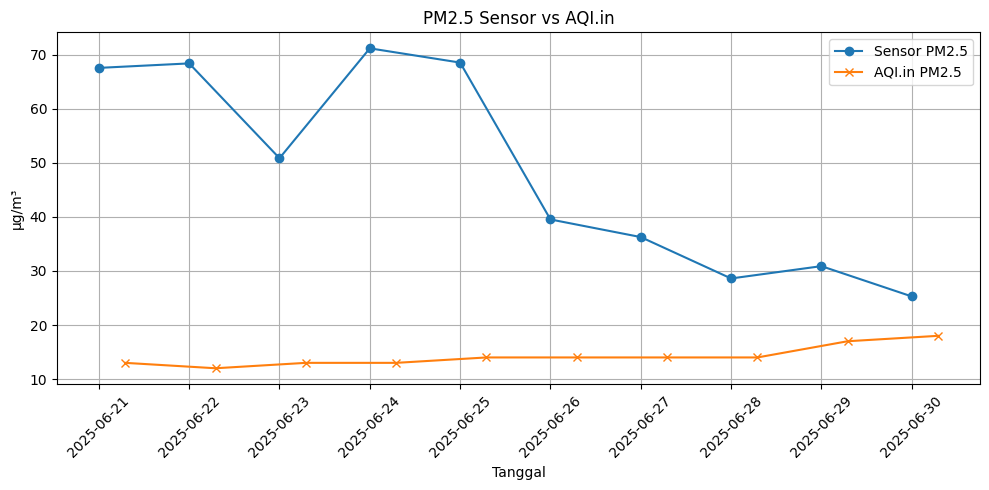

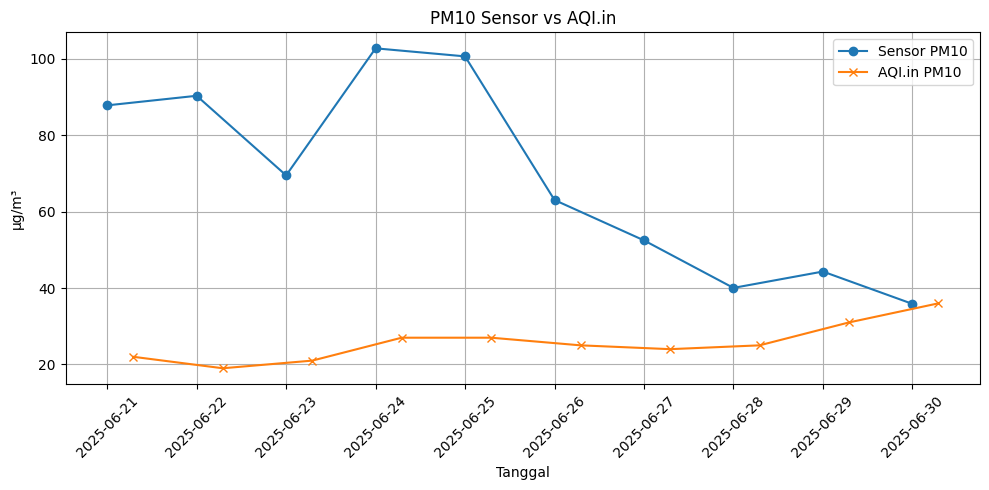

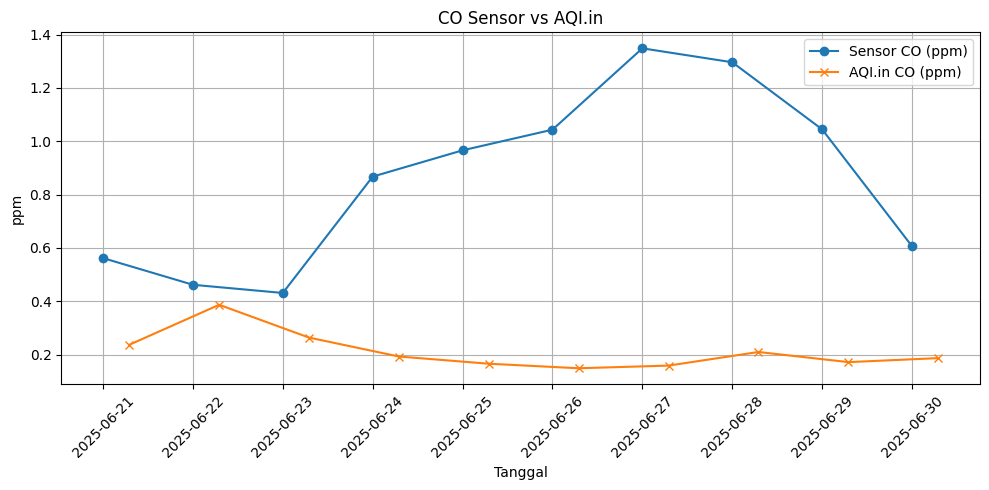

In [32]:
# Plot PM2.5

df_aqi['Tanggal'] = pd.to_datetime(df_aqi['Tanggal'])
df_sensor_daily = df_resampled.copy()
plt.figure(figsize=(10,5))
plt.plot(df_sensor_daily.index, df_sensor_daily['PM2.5'], marker='o', label='Sensor PM2.5')
plt.plot(df_aqi['Tanggal'], df_aqi['AQIin_PM2.5 (µg/m³)'], marker='x', label='AQI.in PM2.5')
plt.title('PM2.5 Sensor vs AQI.in')
plt.xlabel('Tanggal')
plt.ylabel('µg/m³')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Plot PM10
plt.figure(figsize=(10,5))
plt.plot(df_sensor_daily.index, df_sensor_daily['PM10'], marker='o', label='Sensor PM10')
plt.plot(df_aqi['Tanggal'], df_aqi['AQIin_PM10 (µg/m³)'], marker='x', label='AQI.in PM10')
plt.title('PM10 Sensor vs AQI.in')
plt.xlabel('Tanggal')
plt.ylabel('µg/m³')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot CO
plt.figure(figsize=(10,5))
plt.plot(df_sensor_daily.index, df_sensor_daily['CO'], marker='o', label='Sensor CO (ppm)')
plt.plot(df_aqi['Tanggal'], df_aqi['AQIin_CO (ppm)'], marker='x', label='AQI.in CO (ppm)')
plt.title('CO Sensor vs AQI.in')
plt.xlabel('Tanggal')
plt.ylabel('ppm')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression

# Siapkan X (sensor), y (AQI.in)
X = df_resampled['PM2.5'].values.reshape(-1,1)  # sensor
y = df_aqi['AQIin_PM2.5 (µg/m³)'].values  # AQI.in

# Buat model regresi
model = LinearRegression()
model.fit(X, y)

# Prediksi hasil kalibrasi
y_pred = model.predict(X)

# Evaluasi kalibrasi
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Kalibrasi PM2.5 - MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")

Kalibrasi PM2.5 - MSE: 1.484, RMSE: 1.218, MAE: 1.090, R²: 0.531


In [34]:
# X_new = data sensor PM2.5 baru (per hari misalnya)
X_new = df_sensor_daily['PM2.5'].values.reshape(-1,1)

# Kalibrasi
calibrated_pm25 = model.predict(X_new)

# Masukkan hasil kalibrasi ke dataframe kalau mau
df_sensor_daily['PM2.5_calibrated'] = calibrated_pm25


In [35]:
df_sensor_daily

,Temperature,Humidity,PM2.5,PM10,CO,CO2,PM2.5_calibrated
created_at,,,,,,,
2025-06-21 00:00:00+07:00,26.535074,81.027122,67.575608,87.831395,0.562067,403.474040,12.825780
2025-06-22 00:00:00+07:00,26.706698,81.559107,68.404583,90.338073,0.461993,403.466973,12.765364
2025-06-23 00:00:00+07:00,26.757169,76.469586,50.864367,69.498800,0.431280,403.611610,14.043705
2025-06-24 00:00:00+07:00,26.508917,79.586116,71.193836,102.761460,0.867570,405.599358,12.562082
2025-06-25 00:00:00+07:00,26.537367,79.655694,68.553974,100.655575,0.966070,405.878995,12.754476
2025-06-26 00:00:00+07:00,27.075984,73.755490,39.533001,63.049736,1.043497,406.123383,14.869541
2025-06-27 00:00:00+07:00,27.238822,72.416166,36.271635,52.481070,1.348488,407.328424,15.107231
2025-06-28 00:00:00+07:00,25.014329,84.342866,28.614878,40.039573,1.296273,406.624541,15.665260
2025-06-29 00:00:00+07:00,25.630130,80.085291,30.893238,44.322123,1.044667,405.621375,15.499212


In [36]:
df_aqi

,Tanggal,AQIin_PM2.5 (µg/m³),AQIin_PM10 (µg/m³),AQIin_CO (ppb),AQIin_CO (ppm)
0,2025-06-21,13,22,237,0.237
1,2025-06-22,12,19,387,0.387
2,2025-06-23,13,21,264,0.264
3,2025-06-24,13,27,193,0.193
4,2025-06-25,14,27,166,0.166
5,2025-06-26,14,25,149,0.149
6,2025-06-27,14,24,159,0.159
7,2025-06-28,14,25,210,0.210
8,2025-06-29,17,31,172,0.172
9,2025-06-30,18,36,187,0.187


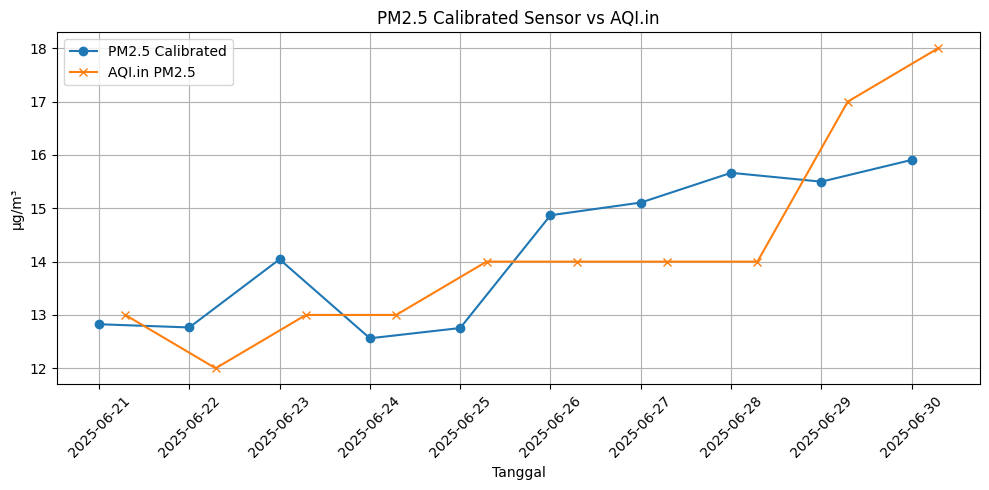

In [39]:
plt.figure(figsize=(10,5))
plt.plot(df_sensor_daily.index, df_sensor_daily['PM2.5_calibrated'], marker='o', label='PM2.5 Calibrated')
plt.plot(df_aqi['Tanggal'], df_aqi['AQIin_PM2.5 (µg/m³)'], marker='x', label='AQI.in PM2.5')
plt.title('PM2.5 Calibrated Sensor vs AQI.in')
plt.xlabel('Tanggal')
plt.ylabel('µg/m³')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()